In [13]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
                              
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


### Choose model for attribution

In [14]:
from transformers import AutoModelForCausalLM, AutoTokenizer
# Choose tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
# model_name = "Qwen/Qwen2.5-3B"
# model_name = "Qwen/Qwen2.5-1.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if device == "cpu":
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

Loading weights: 100%|██████████| 146/146 [00:00<00:00, 6544.84it/s]


In [15]:
front_pad = 2

### Select scope type

In [16]:
# mode = 'Temperature'
# mode = 'Semantic'
mode = 'Fisher'

### Set attribution prompt

In [17]:
string = "Italian: Buon pomeriggio, i miei colleghi ricercatori. English: Good afternoon, my fellow researchers"
string = "German: Dies ist ein Aufsatz über kausale Zuschreibung. English: This is a paper on causal attribution"
# string = "French: Nous l'appelons lentille jacobienne. English: We call it Jacobian Scope"

### Perform attribution

In [ ]:
import JacobianScopes
scores, logits, decoded_tokens, grad_idx, loss_position = JacobianScopes.run_scope(model, 
                                                                                   tokenizer, 
                                                                                   string, 
                                                                                   mode, 
                                                                                   front_pad=2, 
                                                                                   loss_position=-2, 
                                                                                   device=device)
    

### Visualize prediction

In [7]:

logit_vector = logits[loss_position].detach()             
# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)
JacobianScopes.natural_language_pred_plotter(probs, tokenizer, k = 7)

TypeError: Got unsupported ScalarType BFloat16

<Figure size 600x150 with 0 Axes>

### Visualize attribution

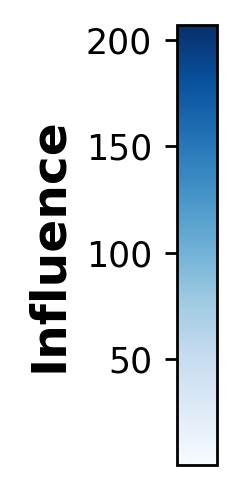

In [13]:

JacobianScopes.natural_language_attribution_plotter(decoded_tokens, grad_idx, scores, mode, loss_position, style = 'B' )